In [ ]:
%pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 843.1 kB/s  0:00:01
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 653.1 kB/s eta 0:00:58
    --------------------------------------- 0.5/38.1 MB 653.1 

In [ ]:
#Imports et chargement du modèle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import LabelEncoder

# Chargement du modèle et des données
xgb = joblib.load(r'C:\Users\hp\predictive-maintenance-ml-datascience-project\models\xgb_model.pkl')
df = pd.read_csv(r'C:\Users\hp\predictive-maintenance-ml-datascience-project\data\ai4i2020.csv')

# Reproduire le même preprocessing
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

# Aligner les noms de colonnes avec ceux utilisés à l'entraînement
df = df.rename(columns={
    'Air temperature [K]': 'Air_temperature_K',
    'Process temperature [K]': 'Process_temperature_K',
    'Rotational speed [rpm]': 'Rotational_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
})

features = [
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Type_encoded'
]

X = df[features]
y = df['Machine failure']

print("Modèle et données chargés avec succès")
print(f"Shape X : {X.shape}")

Modèle et données chargés avec succès
Shape X : (10000, 6)


#  l'explainer SHAP

In [ ]:

# Initialiser l'explainer SHAP pour XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

print(f"Shape shap_values : {shap_values.shape}")
print("Explainer SHAP créé avec succès")

Shape shap_values : (10000, 6)
Explainer SHAP créé avec succès


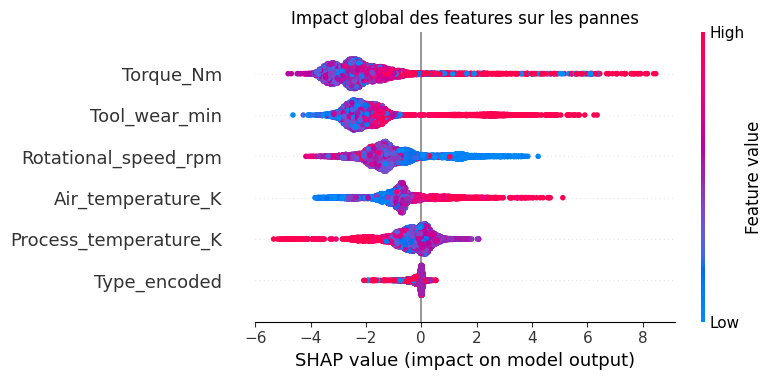

In [ ]:
# Créer l'objet Explanation pour un meilleur affichage
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X.values,
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(explanation, show=False, max_display=6)
plt.title('Impact global des features sur les pannes')
plt.tight_layout()
plt.savefig('../data/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall plot (prédiction individuelle)

Machine analysée : index 50
État réel : PANNE

Valeurs des features :
  Air_temperature_K                   : 298.90
  Process_temperature_K               : 309.10
  Rotational_speed_rpm                : 2861.00
  Torque_Nm                           : 4.60
  Tool_wear_min                       : 143.00
  Type_encoded                        : 1.00


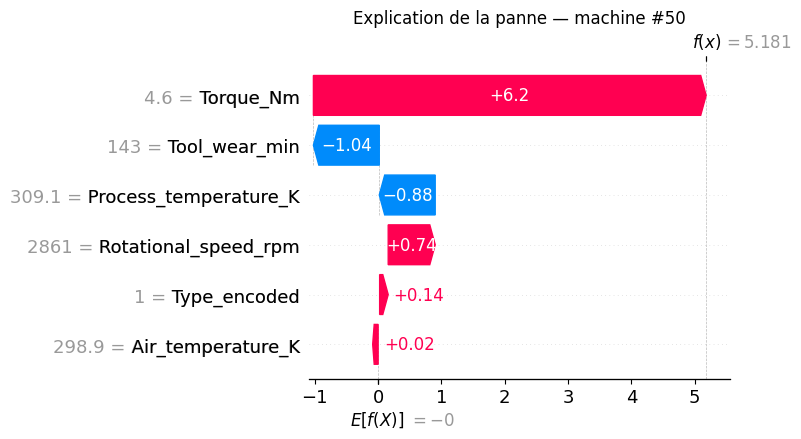

In [ ]:
# Trouver une vraie panne dans le dataset
panne_indices = df[df['Machine failure'] == 1].index.tolist()
idx = panne_indices[0]

print(f"Machine analysée : index {idx}")
print(f"État réel : {'PANNE' if y[idx] == 1 else 'Normal'}")
print(f"\nValeurs des features :")
for f, v in zip(features, X.iloc[idx]):
    print(f"  {f:35s} : {v:.2f}")

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx].values,
        feature_names=features
    ),
    show=False
)
plt.title(f'Explication de la panne — machine #{idx}')
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder l'explainer

In [ ]:
# Sauvegarder l'explainer pour le dashboard Streamlit
joblib.dump(explainer, '../models/shap_explainer.pkl')
joblib.dump(shap_values, '../models/shap_values.pkl')

print("Explainer SHAP sauvegardé dans /models/")
print("  - shap_explainer.pkl")
print("  - shap_values.pkl")

Explainer SHAP sauvegardé dans /models/
  - shap_explainer.pkl
  - shap_values.pkl


# Résumé SHAP

In [ ]:
print("=" * 55)
print("RÉSUMÉ SHAP — INSIGHTS CLÉS")
print("=" * 55)
print("\n Top features par importance SHAP :")
print("  1. Torque_Nm          → feature dominante")
print("  2. Tool_wear_min      → deuxième signal")
print("  3. Rotational_speed   → corrélé au couple")
print("  4. Air_temperature    → impact modéré")
print("\n Interprétation métier :")
print("  Un couple élevé + usure avancée = risque critique")
print("  Ces deux features suffisent à expliquer")
print("  la majorité des pannes du dataset")
print("=" * 55)

RÉSUMÉ SHAP — INSIGHTS CLÉS

 Top features par importance SHAP :
  1. Torque_Nm          → feature dominante
  2. Tool_wear_min      → deuxième signal
  3. Rotational_speed   → corrélé au couple
  4. Air_temperature    → impact modéré

 Interprétation métier :
  Un couple élevé + usure avancée = risque critique
  Ces deux features suffisent à expliquer
  la majorité des pannes du dataset
